# Figures — Every Figure in the Paper

Regenerates the paper's figures from this run's saved outputs and writes them to `figures/` as PNG (dpi 200), under
the file names the manuscript includes. Everything is on the stratified group split.

**Inputs**: `output/master_df.parquet` and `output/pred_*` (from `00` and `03`–`06`), `results/*.json` (`02`–`06`),
and the provision map and labeled addresses from `sp.build_master_df` (for the example graphs and the learning curve).
Trains one model only: a single XGBoost (selected hyperparameters, seed 42) for the learning curve.

**Run order**: after `11_split_comparison`. A small record goes to `results/12_figures.json`.

| File | Figure |
|---|---|
| `chain_length.png` | Chain length CDF, Sybil vs non-Sybil |
| `gp_0x0f.png`, `gp_0x92.png`, `gp_0x47.png` | Gas provision graph examples |
| `non_interacting_dist_from_root.png` | Depth in the gas provision tree, IxI vs IxE (all addresses) |
| `PRandROC.png` | Precision-recall and ROC curves, test set |
| `top_20_feature_importance.png` | XGBoost top 20 features by gain |
| `lgbm_xgb_comparison.png` | XGBoost vs LightGBM top 15 features |
| `learning_curve.png` | XGBoost training and validation F1 by number of trees |

## Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.metrics import f1_score
import sybil_pipeline as sp
warnings.filterwarnings('ignore')

DATA_DIR = './data'
FIG_DIR = 'figures'
os.makedirs(FIG_DIR, exist_ok=True)
C_XGB, C_LGBM, C_LR, C_ENS = '#1565C0', '#2E7D32', '#B71C1C', '#6A1B9A'   # as in sp.plot_curves
C_SYBIL, C_NONSYBIL, C_SHARED = '#B71C1C', '#2E7D32', '#E65100'
plt.rcParams.update({'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
SAVED = []

def save(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')
    SAVED.append(name)
    plt.show()
    print(f'Saved {FIG_DIR}/{name}')

M = pd.read_parquet('output/master_df.parquet', columns=['addr', 'sybil', 'category', 'chain_length', 'depth'])
print(f'{len(M):,} addresses')

434,786 addresses


## 1. Chain length by class (`chain_length.png`)

Empirical CDF of `chain_length` (hops from the wallet to its nearest labeled funder) over all addresses. The x axis
is cut at the 99.5th percentile of all wallets; the title gives the share of each class inside the range.

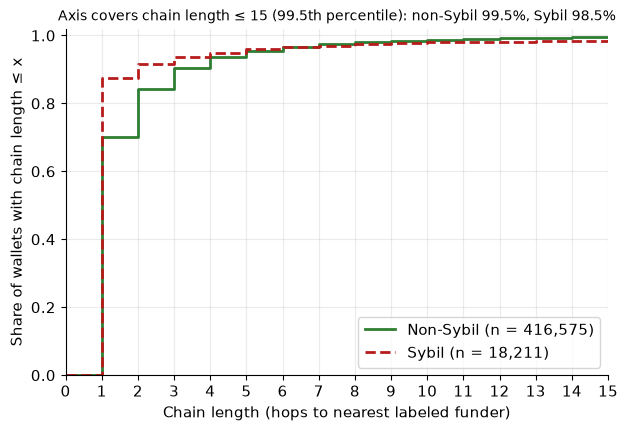

Saved figures/chain_length.png
{'Non-Sybil': np.float64(0.9954), 'Sybil': np.float64(0.9852)}


In [2]:
x_max = int(M['chain_length'].quantile(0.995))
ks = np.arange(0, x_max + 1)
fig, ax = plt.subplots(figsize=(7, 4.5))
cover = {}
for s, name, color, ls in [(0, 'Non-Sybil', C_NONSYBIL, '-'), (1, 'Sybil', C_SYBIL, '--')]:
    cl = M.loc[M['sybil'] == s, 'chain_length'].to_numpy()
    cdf = np.array([(cl <= k).mean() for k in ks])
    cover[name] = cdf[-1]
    ax.step(ks, cdf, where='post', color=color, ls=ls, lw=2, label=f'{name} (n = {len(cl):,})')
ax.set(xlabel='Chain length (hops to nearest labeled funder)', ylabel='Share of wallets with chain length ≤ x',
       xlim=(0, x_max), ylim=(0, 1.02), xticks=ks)
ax.set_title(f'Axis covers chain length ≤ {x_max} (99.5th percentile): non-Sybil {cover["Non-Sybil"]:.1%}, '
             f'Sybil {cover["Sybil"]:.1%}', fontsize=10)
ax.grid(alpha=0.25); ax.legend(loc='lower right')
save(fig, 'chain_length.png')
print({k: round(v, 4) for k, v in cover.items()})

## 2. Gas provision graph examples (`gp_0x0f.png`, `gp_0x92.png`, `gp_0x47.png`)

Each example is the provision chain from a target wallet up to its labeled funder (walk of `tfm`, the first-funder
map before the snapshot cutoff). Circle = LayerZero interactor, square = non-interacting EOA, diamond = labeled
entity; green = non-Sybil, red = Sybil. Arrows point from funder to funded wallet.

The full addresses were matched to the paper's tables by prefix: the target by prefix, category and Sybil label; then
the chain above it in `tfm`. For each example exactly one candidate has a chain whose nodes, in order, carry the
table's prefixes; its flags are asserted below.

In [3]:
df, tfm, anchors = sp.build_master_df(DATA_DIR)
cols = ['addr', 'sybil', 'category', 'chain_length', 'depth']
assert df[cols].equals(M[cols]), 'output/master_df.parquet differs from the rebuilt table'
interactors, sybil = set(df['addr']), dict(zip(df['addr'], df['sybil']))
category = dict(zip(df['addr'], df['category']))

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, gas provision trees (371,764 trees)


All 62 features present ✓  (68.4s)


In [4]:
# Chains from target (first) to labeled root (last), and the paper's flags (interacted, sybil, labeled).
EXAMPLES = {
    'gp_0x0f': [('0xf70768a86bf5f60108554042027aefaf62360d65', 'IxI', (1, 0, 0)),
                ('0xfa55dd6fe7aadae20401b7383a5e06483c298dce', None, (1, 0, 0)),
                ('0x95dacf2fe66ca8f097f182a9860333166d9907bb', None, (0, 0, 0)),
                ('0x28ffe35688ffffd0659aee2e34778b0ae4e193ad', None, (0, 0, 1))],   # HTX Exchange in the paper
    'gp_0x92': [('0x92bb85edb615d98c9c303f18201056b2adeddfb8', 'IxE', (1, 0, 0)),
                ('0xc67bfa3956c9706702bdeca905918228ab8d90bd', None, (0, 0, 0)),
                ('0x8274f4286ba8695cd1f06b42933d7ae2155c289b', None, (0, 0, 0)),
                ('0x62e0b529ca53057658f0604d9c805f2f30727b0b', None, (1, 0, 0)),
                ('0xddfabcdc4d8ffc6d5beaf154f18b778f892a0740', None, (0, 0, 1))],
    'gp_0x47': [('0x47127232949c0bef6677b4d006253169ac0ab6c4', 'IxE', (1, 1, 0)),
                ('0x5f5f102914b677304a37cd50dca26b6fc476176a', None, (0, 0, 0)),
                ('0xe9ba7506dc9a35c1fa39cbdafdcb97436f855f50', None, (1, 1, 0)),
                ('0x0c55fe07ad75c135c797422a5857347b2e5a591e', None, (1, 0, 0)),
                ('0xf5bec430576ff1b82e44ddb5a1c93f6f9d0884f3', None, (0, 0, 1))],
}

def flags(a):
    return (int(a in interactors), int(sybil.get(a, 0)), int(a in anchors))

def chain(a):
    """a, its funder, ... up to a labeled address, a missing funder or a cycle."""
    out = [a]
    while out[-1] not in anchors and tfm.get(out[-1]) is not None and tfm[out[-1]] not in out:
        out.append(tfm[out[-1]])
    return out

for name, rows in EXAMPLES.items():
    addrs = [a for a, _, _ in rows]
    assert chain(addrs[0]) == addrs, name                      # the table is the target's provision chain
    assert category[addrs[0]] == rows[0][1], name
    for a, _, f in rows:
        assert flags(a) == f, (name, a, flags(a), f)
print('All example chains and flags match the paper tables ✓')

All example chains and flags match the paper tables ✓


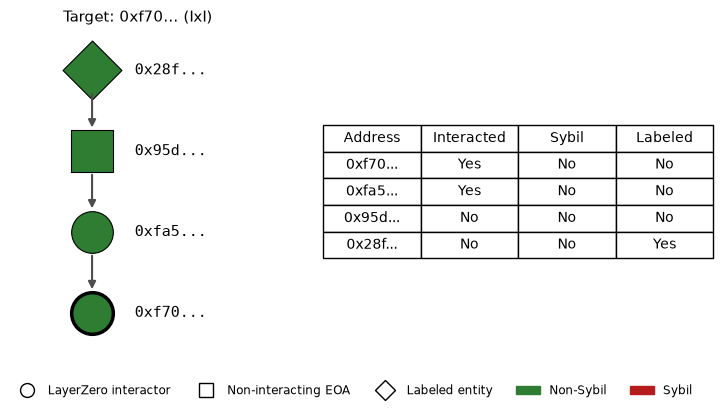

Saved figures/gp_0x0f.png


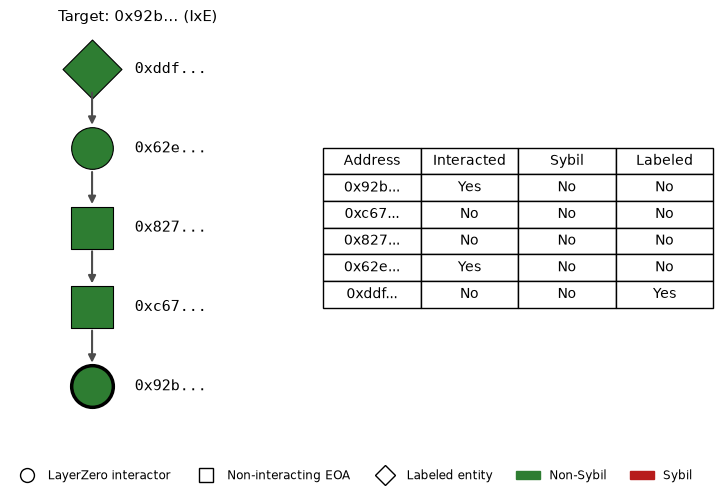

Saved figures/gp_0x92.png


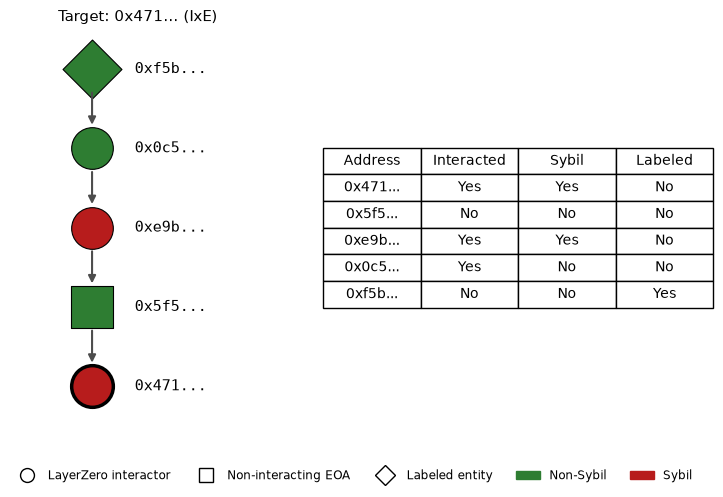

Saved figures/gp_0x47.png


In [5]:
def plot_chain(name):
    rows = EXAMPLES[name][::-1]                                # root at the top
    yn = lambda v: 'Yes' if v else 'No'
    fig, (ax, at) = plt.subplots(1, 2, figsize=(9, 0.95 * len(rows) + 0.4), gridspec_kw=dict(width_ratios=[1, 1.6]))
    for i, (a, _, (inter, syb, lab)) in enumerate(rows):
        y = -i
        marker = 'D' if lab else ('o' if inter else 's')
        ax.scatter(0, y, s=900, marker=marker, color=C_SYBIL if syb else C_NONSYBIL, edgecolor='black',
                   lw=2.5 if i == len(rows) - 1 else 0.8, zorder=3)
        ax.text(0.28, y, a[:5] + '...', va='center', fontsize=11, family='monospace')
        if i:
            ax.annotate('', xy=(0, y), xytext=(0, y + 1),
                        arrowprops=dict(arrowstyle='-|>', color='0.3', lw=1.5, shrinkA=17, shrinkB=17))
    ax.set(xlim=(-0.5, 1.1), ylim=(-len(rows) + 0.5, 0.5)); ax.axis('off')
    ax.set_title(f'Target: {rows[-1][0][:5]}... ({rows[-1][1]})', fontsize=11)
    cell = [[a[:5] + '...', yn(f[0]), yn(f[1]), yn(f[2])] for a, _, f in rows[::-1]]
    t = at.table(cellText=cell, colLabels=['Address', 'Interacted', 'Sybil', 'Labeled'], loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1, 1.6)
    at.axis('off')
    handles = [Line2D([], [], marker=m, ls='', color='white', markeredgecolor='black', markersize=10, label=l)
               for m, l in [('o', 'LayerZero interactor'), ('s', 'Non-interacting EOA'), ('D', 'Labeled entity')]]
    handles += [Patch(color=C_NONSYBIL, label='Non-Sybil'), Patch(color=C_SYBIL, label='Sybil')]
    fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8.5, frameon=False, bbox_to_anchor=(0.5, -0.02))
    save(fig, f'{name}.png')

for name in EXAMPLES:
    plot_chain(name)

## 3. Depth in the gas provision tree (`non_interacting_dist_from_root.png`)

`depth` is the number of hops from the wallet to the root of its unlabeled gas provision tree. Drawn on **all**
IxI and IxE addresses (the submitted figure used validation plus test only). The last bar pools the tail.

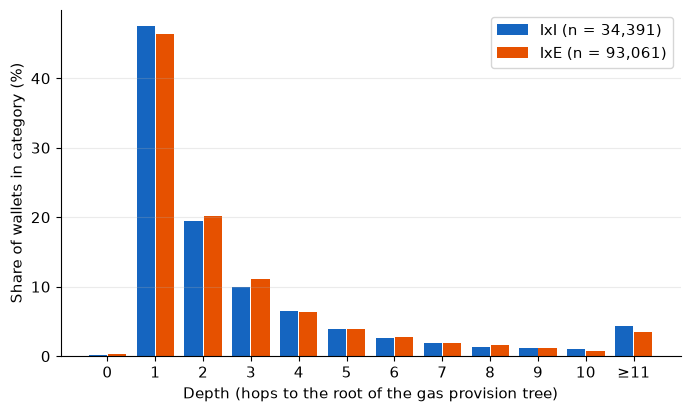

Saved figures/non_interacting_dist_from_root.png
{'IxI': 34391, 'IxE': 93061}


In [6]:
D_MAX = 10
labels = [str(d) for d in range(D_MAX + 1)] + [f'≥{D_MAX + 1}']
fig, ax = plt.subplots(figsize=(8, 4.5))
n_by_cat = {}
for j, (cat, color) in enumerate([('IxI', C_XGB), ('IxE', C_SHARED)]):
    d = M.loc[M['category'] == cat, 'depth'].clip(upper=D_MAX + 1).astype(int)
    n_by_cat[cat] = len(d)
    share = d.value_counts(normalize=True).reindex(range(D_MAX + 2), fill_value=0) * 100
    ax.bar(np.arange(D_MAX + 2) + (j - 0.5) * 0.4, share, width=0.38, color=color, label=f'{cat} (n = {len(d):,})')
ax.set_xticks(range(D_MAX + 2), labels)
ax.set(xlabel='Depth (hops to the root of the gas provision tree)', ylabel='Share of wallets in category (%)')
ax.grid(axis='y', alpha=0.25); ax.legend()
save(fig, 'non_interacting_dist_from_root.png')
print(n_by_cat)

## 4. Precision-recall and ROC curves, test set (`PRandROC.png`)

From the saved predictions of `03`–`06` via `sp.evaluate` (the function that produced the saved metrics); AP and
AUROC are asserted equal to `results/`.

XGBoost              AP 0.7645  AUROC 0.9657  (match results/03_xgboost_sybil.json)


LightGBM             AP 0.7696  AUROC 0.9683  (match results/04_lightgbm_sybil.json)


Logistic Regression  AP 0.1656  AUROC 0.8368  (match results/05_logistic_regression_sybil.json)


Cross-Ensemble       AP 0.7699  AUROC 0.9683  (match results/06_cross_ensemble_sybil.json)


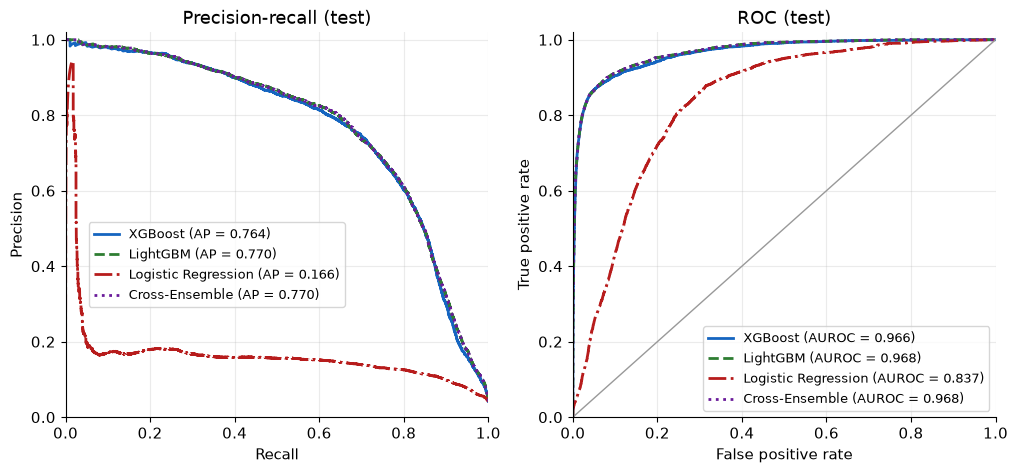

Saved figures/PRandROC.png


In [7]:
MODELS = [('XGBoost', '03_xgboost_sybil', 'prob_xgb', C_XGB, '-'),
          ('LightGBM', '04_lightgbm_sybil', 'prob_lgbm', C_LGBM, '--'),
          ('Logistic Regression', '05_logistic_regression_sybil', 'prob_lr', C_LR, '-.'),
          ('Cross-Ensemble', '06_cross_ensemble_sybil', 'prob_ens', C_ENS, ':')]
fig, (a_pr, a_roc) = plt.subplots(1, 2, figsize=(12, 5))
for label, nb, col, color, ls in MODELS:
    v, t = sp.load_predictions(nb, 'val'), sp.load_predictions(nb, 'test')
    r = sp.evaluate(label, v['y'], v[col], t['y'], t[col])
    saved = sp.load_results(nb)['models'][-1]
    assert abs(r['ap'] - saved['ap']) < 1e-9 and abs(r['auroc'] - saved['auroc']) < 1e-9, nb
    a_pr.plot(r['rec_c'], r['prc'], color=color, ls=ls, lw=2, label=f"{label} (AP = {r['ap']:.3f})")
    a_roc.plot(r['fpr'], r['tpr'], color=color, ls=ls, lw=2, label=f"{label} (AUROC = {r['auroc']:.3f})")
    print(f"{label:<20} AP {r['ap']:.4f}  AUROC {r['auroc']:.4f}  (match results/{nb}.json)")
a_roc.plot([0, 1], [0, 1], color='0.6', lw=1)
a_pr.set(xlabel='Recall', ylabel='Precision', title='Precision-recall (test)', xlim=(0, 1), ylim=(0, 1.02))
a_roc.set(xlabel='False positive rate', ylabel='True positive rate', title='ROC (test)', xlim=(0, 1), ylim=(0, 1.02))
a_pr.legend(loc='lower left', bbox_to_anchor=(0.04, 0.27), fontsize=9)
a_roc.legend(loc='lower right', fontsize=9)
for a in (a_pr, a_roc):
    a.grid(alpha=0.25)
save(fig, 'PRandROC.png')

## 5. Feature importance (`top_20_feature_importance.png`, `lgbm_xgb_comparison.png`)

Normalized total gain, mean over the three seeds, as saved by `03` and `04`.

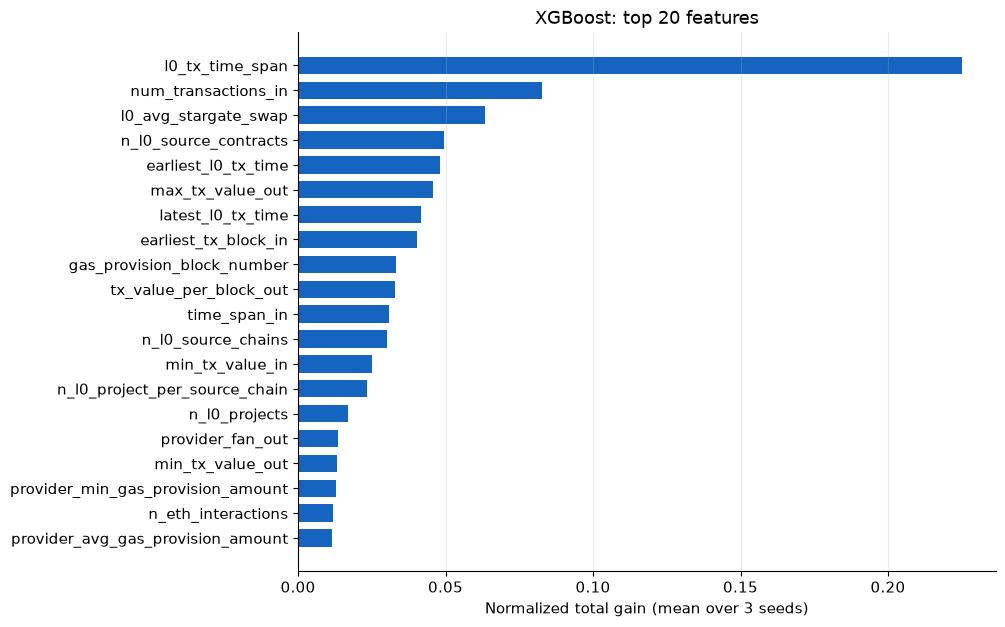

Saved figures/top_20_feature_importance.png


In [8]:
imp = {nb: pd.Series(sp.load_results(nb)['importance']).sort_values(ascending=False)
       for nb in ['03_xgboost_sybil', '04_lightgbm_sybil']}
top = imp['03_xgboost_sybil'].head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top.index[::-1], top.values[::-1], color=C_XGB, height=0.7)
ax.set(xlabel='Normalized total gain (mean over 3 seeds)', title='XGBoost: top 20 features')
ax.grid(axis='x', alpha=0.25)
save(fig, 'top_20_feature_importance.png')

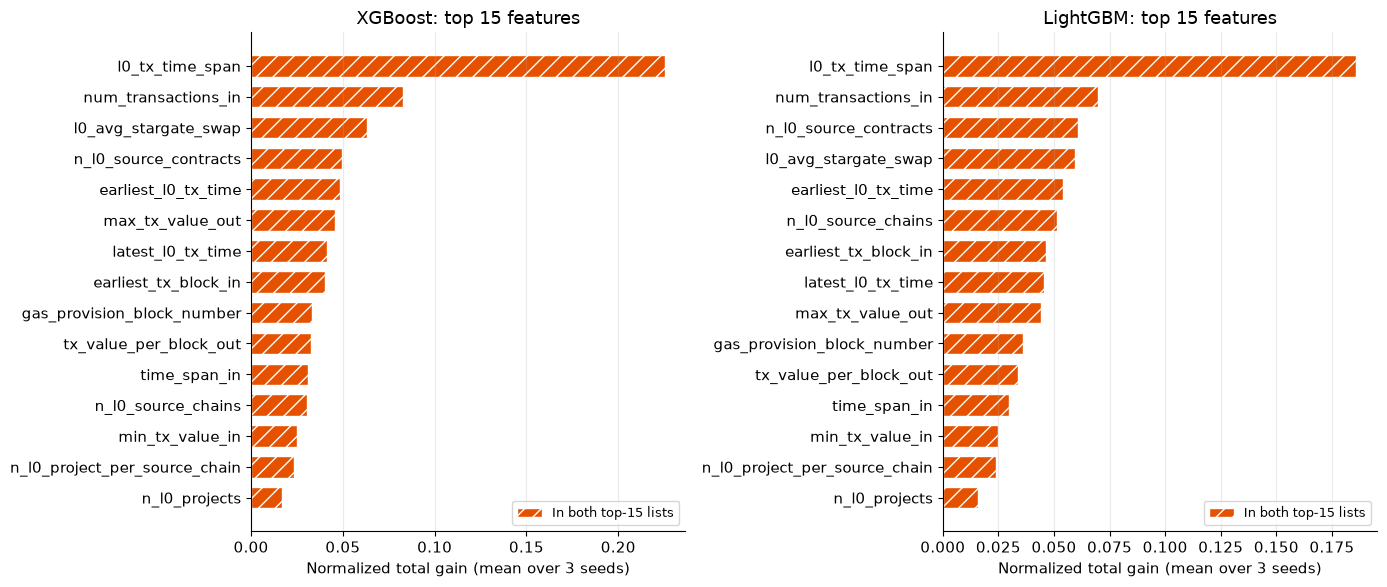

Saved figures/lgbm_xgb_comparison.png
Features in both top-15 lists: 15 of 15
['earliest_l0_tx_time', 'earliest_tx_block_in', 'gas_provision_block_number', 'l0_avg_stargate_swap', 'l0_tx_time_span', 'latest_l0_tx_time', 'max_tx_value_out', 'min_tx_value_in', 'n_l0_project_per_source_chain', 'n_l0_projects', 'n_l0_source_chains', 'n_l0_source_contracts', 'num_transactions_in', 'time_span_in', 'tx_value_per_block_out']


In [9]:
N = 15
tx, tl = imp['03_xgboost_sybil'].head(N), imp['04_lightgbm_sybil'].head(N)
shared = set(tx.index) & set(tl.index)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, s, color, title in [(axes[0], tx, C_XGB, 'XGBoost'), (axes[1], tl, C_LGBM, 'LightGBM')]:
    is_sh = [f in shared for f in s.index[::-1]]
    ax.barh(s.index[::-1], s.values[::-1], height=0.7, color=[C_SHARED if x else color for x in is_sh],
            edgecolor='white')
    for bar, x in zip(ax.patches, is_sh):
        if x:
            bar.set_hatch('//')
    ax.set(xlabel='Normalized total gain (mean over 3 seeds)', title=f'{title}: top {N} features')
    ax.grid(axis='x', alpha=0.25)
    handles = [Patch(facecolor=C_SHARED, hatch='//', edgecolor='white', label=f'In both top-{N} lists')]
    if not all(is_sh):
        handles.insert(0, Patch(color=color, label=f'{title} only'))
    ax.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
save(fig, 'lgbm_xgb_comparison.png')
print(f'Features in both top-{N} lists: {len(shared)} of {N}')
print(sorted(shared))

## 6. Learning curve (`learning_curve.png`)

One XGBoost with the hyperparameters selected by `02` and seed 42 (the first of the three seeds in `03`), on the
group split. The training set is also passed to `eval_set`, ahead of validation, so early stopping still uses
validation (the last set) and the trees are those of `03`'s first seed (asserted). F1 is computed at each set's own
F1-maximizing threshold. The training F1 is on the upsampled (1:1) training partition, so its level is not directly
comparable with the validation F1 (4.2 % Sybil).

In [10]:
PARAMS = sp.load_selected_params()[0]
S = sp.make_splits(df, sp.FEATS, method='group', seed=sp.SEED)
m = sp.xgb_model(PARAMS, 42)
m.fit(S['X_train'], S['y_train'], eval_set=[(S['X_train'], S['y_train']), (S['X_val'], S['y_val'])], verbose=False)
best_it = int(m.best_iteration)
assert best_it == sp.load_results('03_xgboost_sybil')['rounds'][0], best_it
n_trees = m.get_booster().num_boosted_rounds()
print(f'best_iteration = {best_it} (matches 03, seed 42); trees fitted = {n_trees}')

best_iteration = 1679 (matches 03, seed 42); trees fitted = 1730


In [11]:
def f1_at_best(X, y, k):
    p = m.predict_proba(X, iteration_range=(0, k))[:, 1]
    return f1_score(y, (p >= sp.best_f1_threshold(y, p)).astype(int))

checkpoints = sorted(set(range(50, best_it + 52, 50)) | {best_it + 1, n_trees})
curve = pd.DataFrame([dict(trees=k, train_f1=f1_at_best(S['X_train'], S['y_train'], k),
                           val_f1=f1_at_best(S['X_val'], S['y_val'], k)) for k in checkpoints]).set_index('trees')
final = curve.loc[best_it + 1]
val_f1_02 = sp.load_results('02_hyperparameter_search')['xgb_selected_val']['val_f1']
assert abs(final['val_f1'] - val_f1_02) < 1e-4, (final['val_f1'], val_f1_02)
print(f"At {best_it + 1} trees: train F1 {final['train_f1']:.4f}, validation F1 {final['val_f1']:.4f} "
      f"(02: {val_f1_02:.4f})")

At 1680 trees: train F1 0.9993, validation F1 0.7032 (02: 0.7032)


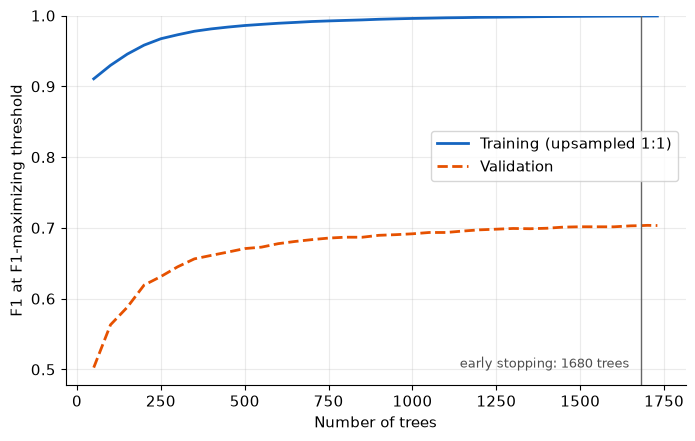

Saved figures/learning_curve.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(curve.index, curve['train_f1'], color=C_XGB, lw=2, label='Training (upsampled 1:1)')
ax.plot(curve.index, curve['val_f1'], color=C_SHARED, lw=2, ls='--', label='Validation')
ax.axvline(best_it + 1, color='0.4', lw=1)
ax.annotate(f'early stopping: {best_it + 1} trees', xy=(best_it + 1, curve['val_f1'].min()),
            xytext=(-8, 0), textcoords='offset points', ha='right', fontsize=9, color='0.3')
ax.set(xlabel='Number of trees', ylabel='F1 at F1-maximizing threshold', ylim=(None, 1.0))
ax.grid(alpha=0.25); ax.legend(loc='center right', bbox_to_anchor=(1, 0.62))
save(fig, 'learning_curve.png')

## Save record

In [13]:
sp.save_results([], '12_figures', extra=dict(
    figures=SAVED,
    chain_length_axis=dict(x_max=x_max, coverage={k: float(v) for k, v in cover.items()}),
    depth_n_by_category=n_by_cat,
    examples={name: [dict(addr=a, interacted=f[0], sybil=f[1], labeled=f[2]) for a, _, f in rows]
              for name, rows in EXAMPLES.items()},
    learning_curve=dict(best_iteration=best_it, trees=int(best_it + 1),
                        train_f1=float(final['train_f1']), val_f1=float(final['val_f1'])),
    shared_top15=len(shared),
))
assert len(SAVED) == 9

Saved results/12_figures.json
